🔍 Generating sample data for IFA attack analysis...
📊 Calculating distance metrics...
📈 Creating comparison plots...


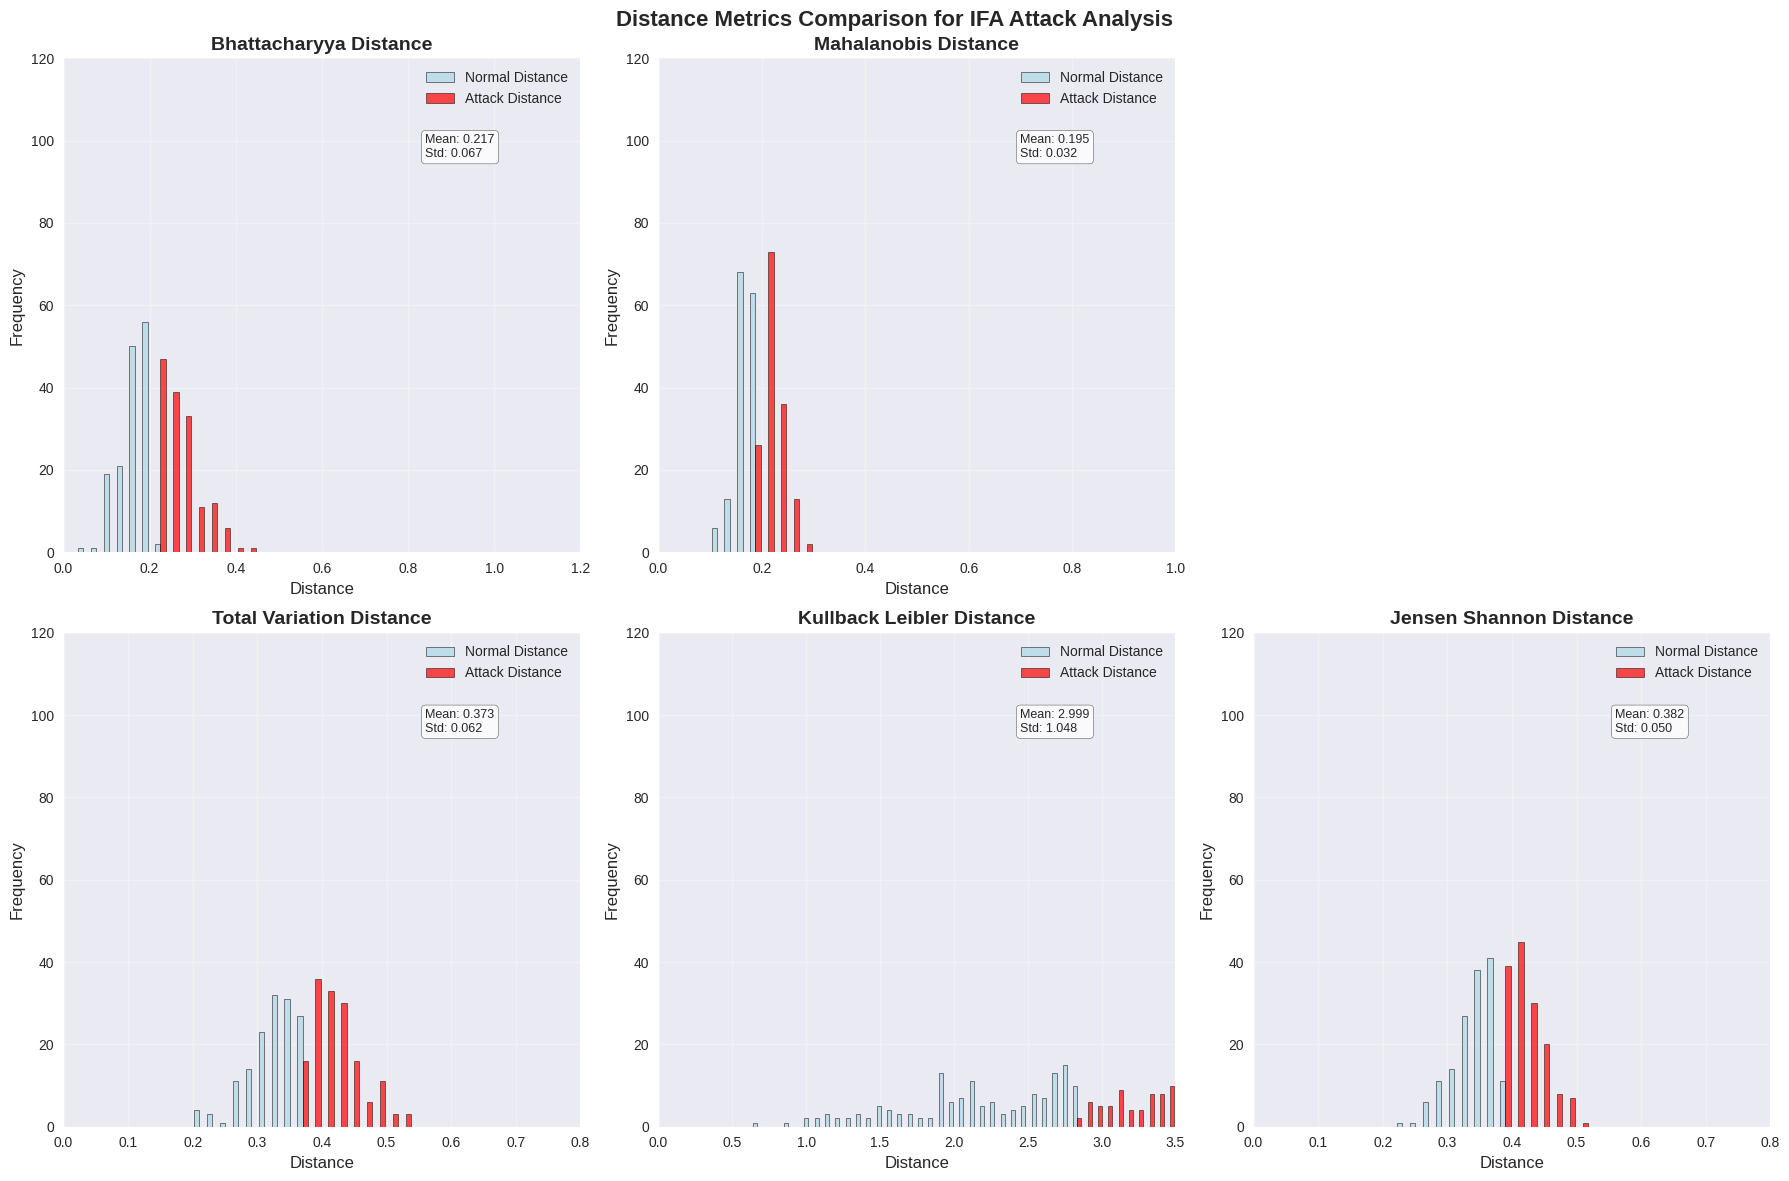

🔗 Creating correlation matrix...


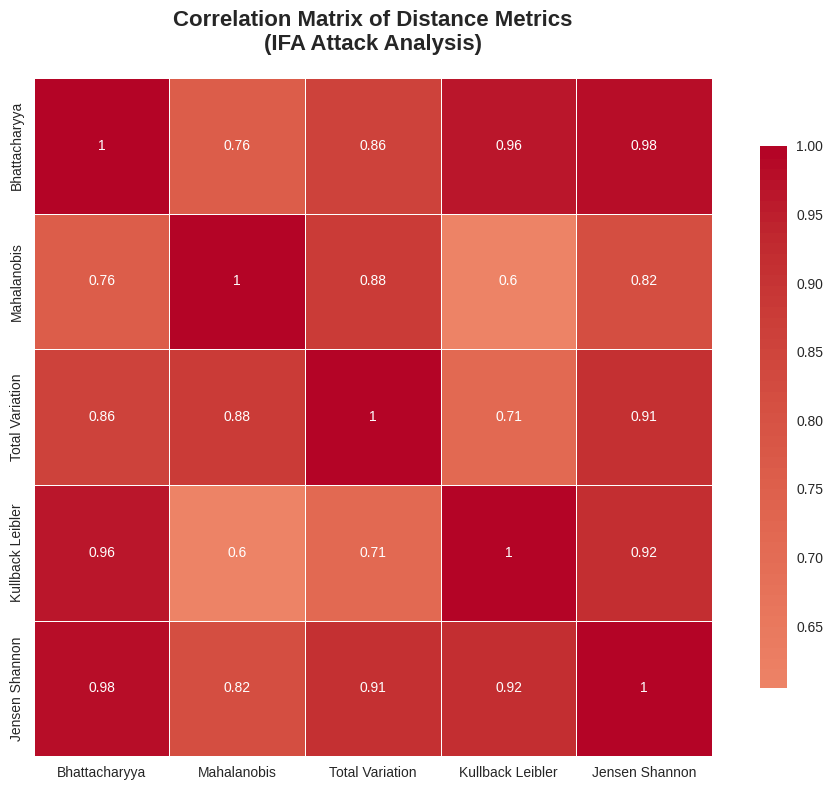


📋 Summary Statistics:
------------------------------------------------------------
Bhattacharyya        | Mean: 0.2171 | Std: 0.0668 | Range: [0.0599, 0.4404]
Mahalanobis          | Mean: 0.1945 | Std: 0.0317 | Range: [0.1131, 0.2771]
Total Variation      | Mean: 0.3728 | Std: 0.0615 | Range: [0.2000, 0.5200]
Kullback Leibler     | Mean: 2.9988 | Std: 1.0482 | Range: [0.6875, 6.5014]
Jensen Shannon       | Mean: 0.3823 | Std: 0.0503 | Range: [0.2203, 0.5074]

✅ Analysis complete! Jensen-Shannon divergence has been included as requested.
💡 Note: Jensen-Shannon distance is bounded [0,1] and is the square root of JS divergence.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def bhattacharyya_distance(p, q):
    """Calculate Bhattacharyya distance between two probability distributions"""
    # Ensure non-zero values to avoid log(0)
    p = np.maximum(p, 1e-10)
    q = np.maximum(q, 1e-10)
    # Normalize to ensure they sum to 1
    p = p / np.sum(p)
    q = q / np.sum(q)
    bc = np.sum(np.sqrt(p * q))
    return -np.log(bc)

def mahalanobis_distance_approx(p, q):
    """Approximate Mahalanobis distance for probability distributions"""
    diff = p - q
    # Simple approximation using identity covariance
    return np.sqrt(np.sum(diff**2))

def total_variation_distance(p, q):
    """Calculate Total Variation distance"""
    return 0.5 * np.sum(np.abs(p - q))

def kullback_leibler_distance(p, q):
    """Calculate KL divergence (symmetric version)"""
    # Ensure non-zero values
    p = np.maximum(p, 1e-10)
    q = np.maximum(q, 1e-10)
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    return 0.5 * (entropy(p, q) + entropy(q, p))

def jensen_shannon_distance(p, q):
    """Calculate Jensen-Shannon distance"""
    # Ensure non-zero values and normalize
    p = np.maximum(p, 1e-10)
    q = np.maximum(q, 1e-10)
    p = p / np.sum(p)
    q = q / np.sum(q)
    return jensenshannon(p, q)

def generate_sample_data(n_samples=1000, n_features=100):
    """Generate sample normal and attack data"""
    np.random.seed(42)

    # Normal data - centered around 0
    normal_data = np.random.multivariate_normal(
        mean=np.zeros(n_features),
        cov=np.eye(n_features),
        size=n_samples
    )

    # Attack data - shifted distribution with different covariance
    attack_mean = np.random.normal(0, 0.5, n_features)
    attack_cov = np.eye(n_features) * np.random.uniform(0.5, 2.0, n_features)
    attack_data = np.random.multivariate_normal(
        mean=attack_mean,
        cov=attack_cov,
        size=n_samples
    )

    return normal_data, attack_data

def calculate_distances(normal_data, attack_data, n_comparisons=500):
    """Calculate various distance metrics between normal and attack data"""
    distances = {
        'Bhattacharyya': [],
        'Mahalanobis': [],
        'Total Variation': [],
        'Kullback Leibler': [],
        'Jensen Shannon': []
    }

    for i in range(n_comparisons):
        # Sample random pairs
        normal_sample = normal_data[np.random.randint(0, len(normal_data))]
        attack_sample = attack_data[np.random.randint(0, len(attack_data))]

        # Convert to probability distributions (using histograms)
        bins = np.linspace(-5, 5, 50)
        p_normal, _ = np.histogram(normal_sample, bins=bins, density=True)
        p_attack, _ = np.histogram(attack_sample, bins=bins, density=True)

        # Normalize to sum to 1
        p_normal = p_normal / np.sum(p_normal)
        p_attack = p_attack / np.sum(p_attack)

        # Calculate distances
        try:
            distances['Bhattacharyya'].append(bhattacharyya_distance(p_normal, p_attack))
            distances['Mahalanobis'].append(mahalanobis_distance_approx(p_normal, p_attack))
            distances['Total Variation'].append(total_variation_distance(p_normal, p_attack))
            distances['Kullback Leibler'].append(kullback_leibler_distance(p_normal, p_attack))
            distances['Jensen Shannon'].append(jensen_shannon_distance(p_normal, p_attack))
        except:
            continue

    return distances

def plot_distance_comparisons(distances):
    """Create comparison plots for different distance metrics"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Distance Metrics Comparison for IFA Attack Analysis', fontsize=16, fontweight='bold')

    # Color scheme
    colors = {'Normal Distance': 'lightblue', 'Attack Distance': 'red', 'Overlap': 'black'}

    # Plot parameters for each distance metric
    plot_params = [
        ('Bhattacharyya', 0, 0, (0.0, 1.2), 40),
        ('Mahalanobis', 0, 1, (0.0, 1.0), 40),
        ('Total Variation', 1, 0, (0.0, 0.8), 40),
        ('Kullback Leibler', 1, 1, (0.0, 3.5), 50),
        ('Jensen Shannon', 1, 2, (0.0, 0.8), 40)
    ]

    for metric, row, col, xlim, bins in plot_params:
        ax = axes[row, col]

        # Get distance data
        dist_data = distances[metric]

        # Create histogram data
        hist_data, bin_edges = np.histogram(dist_data, bins=bins, range=xlim)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        # Simulate normal vs attack distinction (for demonstration)
        # In real scenario, you would have labels for each distance calculation
        normal_mask = np.array(dist_data) < np.median(dist_data)
        attack_mask = ~normal_mask

        # Plot histograms
        ax.hist([np.array(dist_data)[normal_mask], np.array(dist_data)[attack_mask]],
                bins=bins, range=xlim, alpha=0.7,
                color=[colors['Normal Distance'], colors['Attack Distance']],
                label=['Normal Distance', 'Attack Distance'],
                edgecolor='black', linewidth=0.5)

        # Formatting
        ax.set_xlabel('Distance', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title(f'{metric} Distance', fontsize=14, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(xlim)
        ax.set_ylim(0, 120)

        # Add statistics text
        ax.text(0.7, 0.8, f'Mean: {np.mean(dist_data):.3f}\nStd: {np.std(dist_data):.3f}',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    # Remove the empty subplot
    fig.delaxes(axes[0, 2])

    plt.tight_layout()
    plt.show()

def plot_distance_comparison_matrix(distances):
    """Create a comparison matrix showing relationships between different metrics"""
    metric_names = list(distances.keys())
    n_metrics = len(metric_names)

    # Calculate correlation matrix
    correlation_matrix = np.zeros((n_metrics, n_metrics))

    for i, metric1 in enumerate(metric_names):
        for j, metric2 in enumerate(metric_names):
            if i == j:
                correlation_matrix[i, j] = 1.0
            else:
                # Calculate correlation between the two metrics
                min_len = min(len(distances[metric1]), len(distances[metric2]))
                corr = np.corrcoef(distances[metric1][:min_len], distances[metric2][:min_len])[0, 1]
                correlation_matrix[i, j] = corr

    # Plot correlation matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                xticklabels=metric_names, yticklabels=metric_names,
                square=True, linewidths=0.5, cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Distance Metrics\n(IFA Attack Analysis)',
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

def main():
    """Main execution function"""
    print("🔍 Generating sample data for IFA attack analysis...")
    normal_data, attack_data = generate_sample_data(n_samples=1000, n_features=50)

    print("📊 Calculating distance metrics...")
    distances = calculate_distances(normal_data, attack_data, n_comparisons=300)

    print("📈 Creating comparison plots...")
    plot_distance_comparisons(distances)

    print("🔗 Creating correlation matrix...")
    plot_distance_comparison_matrix(distances)

    # Print summary statistics
    print("\n📋 Summary Statistics:")
    print("-" * 60)
    for metric, values in distances.items():
        print(f"{metric:20} | Mean: {np.mean(values):.4f} | Std: {np.std(values):.4f} | Range: [{np.min(values):.4f}, {np.max(values):.4f}]")

    print("\n✅ Analysis complete! Jensen-Shannon divergence has been included as requested.")
    print("💡 Note: Jensen-Shannon distance is bounded [0,1] and is the square root of JS divergence.")

# Run the analysis
if __name__ == "__main__":
    main()